## 13 · Evaluación final de la extensión Pareto + KNN

Este notebook evalúa la extensión *Pareto + KNN* creada en el notebook 12. No vuelve a evaluar todo el recomendador, sino que se centra en comprobar cómo funciona la parte de **KNN** dentro del sistema.


Se mantienen los cuatro modos: *TRANSIT, WALK, BICYCLE y CAR.*

La evaluación analiza principalmente:

- Cuánto mejora la eficiencia al aplicar Pareto antes de KNN;
- Cuánto se pierde en similitud al exigir esa eficiencia;
- Si el resultado cambia según el modo de transporte;
- Cómo cambian los vecinos al modificar el perfil, las características utilizadas o el valor de k;
- Si los resultados son reproducibles y coinciden con los del notebook 12.

Que *Pareto_KNN* devuelva solo alternativas Pareto es algo propio del método. Lo interesante del experimento es medir cuánto cambia **KNN** y qué coste en similitud supone aplicar esa restricción.

## 13.1 Librerías y configuración

Se emplean únicamente dependencias ya utilizadas en el proyecto. Para los intervalos de incertidumbre se utiliza **bootstrap** no paramétrico, evitando introducir supuestos de normalidad sobre las 36 combinaciones *destino–modo–perfil*.


In [ ]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
BOOTSTRAP_ITERATIONS = 5000
CONFIDENCE_LEVEL = 0.95

EXPECTED_MODES = {"TRANSIT", "WALK", "BICYCLE", "CAR"}
EXPECTED_METHODS = {"KNN_global", "Pareto_KNN"}
EXPECTED_K_VALUES = {3, 5, 7, 10}
FLOAT_TOL = 1e-10


## 13.2 Localización del proyecto y contrato con el notebook 12

El notebook consume exclusivamente resultados ya generados por el 12. La evaluación queda desacoplada del cálculo de vecinos y puede reproducirse sin volver a reconstruir KNN.


In [ ]:
def find_project_root() -> Path:
    current = Path.cwd().resolve()
    required = (
        Path("data")
        / "results"
        / "knn12_multimodal_validation_report.csv"
    )

    for candidate in [current, *current.parents]:
        if (candidate / required).exists():
            return candidate

    raise FileNotFoundError(
        "No se ha localizado la raíz del proyecto. "
        "Ejecuta primero el notebook 12 y abre este cuaderno "
        "desde la carpeta del proyecto o desde notebooks/."
    )


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "data" / "results"

INPUT_PATHS = {
    "validation": RESULTS_DIR / "knn12_multimodal_validation_report.csv",
    "anchors": RESULTS_DIR / "knn12_multimodal_anchors.csv",
    "availability": RESULTS_DIR / "knn12_multimodal_availability_audit.csv",
    "neighbors": RESULTS_DIR / "knn12_multimodal_neighbors_k5.csv",
    "evaluation": RESULTS_DIR / "knn12_multimodal_evaluation_k5.csv",
    "comparison": RESULTS_DIR / "knn12_multimodal_strategy_comparison.csv",
    "overlap": RESULTS_DIR / "knn12_multimodal_strategy_overlap.csv",
    "mode_summary": RESULTS_DIR / "knn12_multimodal_mode_summary.csv",
    "profile_overlap": RESULTS_DIR / "knn12_multimodal_profile_overlap.csv",
    "feature_overlap": RESULTS_DIR / "knn12_multimodal_feature_space_overlap.csv",
    "sensitivity": RESULTS_DIR / "knn12_multimodal_sensitivity_summary.csv",
    "empirical": RESULTS_DIR / "knn12_multimodal_empirical_indicators.csv",
    "summary12": RESULTS_DIR / "knn12_multimodal_summary.csv",
}

OUTPUT_PATHS = {
    "bootstrap": RESULTS_DIR / "evaluation13_multimodal_bootstrap_summary.csv",
    "mode_tradeoff": RESULTS_DIR / "evaluation13_multimodal_tradeoff_by_mode.csv",
    "profile": RESULTS_DIR / "evaluation13_multimodal_profile_differentiation.csv",
    "feature": RESULTS_DIR / "evaluation13_multimodal_feature_ablation.csv",
    "sensitivity": RESULTS_DIR / "evaluation13_multimodal_k_sensitivity.csv",
    "findings": RESULTS_DIR / "evaluation13_multimodal_empirical_findings.csv",
    "case_study": RESULTS_DIR / "evaluation13_multimodal_case_study.csv",
    "validation": RESULTS_DIR / "evaluation13_multimodal_validation_report.csv",
    "summary": RESULTS_DIR / "evaluation13_multimodal_summary.csv",
}

print("Raíz del proyecto:", PROJECT_ROOT)
print("Directorio de resultados:", RESULTS_DIR)


Raíz del proyecto: /home/aclaver/TFG-INFO
Directorio de resultados: /home/aclaver/TFG-INFO/data/results


## 13.3 Carga de resultados y comprobación del contrato

Antes de analizar resultados se comprueba que el notebook 12 terminó correctamente y que las tablas necesarias conservan la estructura esperada.


In [ ]:
missing_paths = [
    path for path in INPUT_PATHS.values()
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Faltan resultados necesarios del notebook 12:\n"
        + "\n".join(
            f"- {path.relative_to(PROJECT_ROOT)}"
            for path in missing_paths
        )
    )

validation12 = pd.read_csv(INPUT_PATHS["validation"])
anchors = pd.read_csv(INPUT_PATHS["anchors"])
availability = pd.read_csv(INPUT_PATHS["availability"])
neighbors = pd.read_csv(INPUT_PATHS["neighbors"])
evaluation = pd.read_csv(INPUT_PATHS["evaluation"])
comparison = pd.read_csv(INPUT_PATHS["comparison"])
strategy_overlap = pd.read_csv(INPUT_PATHS["overlap"])
mode_summary12 = pd.read_csv(INPUT_PATHS["mode_summary"])
profile_overlap = pd.read_csv(INPUT_PATHS["profile_overlap"])
feature_overlap = pd.read_csv(INPUT_PATHS["feature_overlap"])
sensitivity = pd.read_csv(INPUT_PATHS["sensitivity"])
empirical12 = pd.read_csv(INPUT_PATHS["empirical"])
summary12 = pd.read_csv(INPUT_PATHS["summary12"], index_col=0)

print("Validaciones 12:", validation12.shape)
print("Escenarios ancla:", anchors.shape)
print("Vecinos k=5:", neighbors.shape)
print("Comparación de estrategias:", comparison.shape)
print("Sensibilidad a k:", sensitivity.shape)


Validaciones 12: (23, 5)
Escenarios ancla: (36, 15)
Vecinos k=5: (318, 26)
Comparación de estrategias: (36, 23)
Sensibilidad a k: (32, 9)


In [ ]:
def coerce_bool_series(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)

    normalized = series.astype(str).str.strip().str.lower()
    mapping = {
        "true": True,
        "1": True,
        "yes": True,
        "si": True,
        "sí": True,
        "false": False,
        "0": False,
        "no": False,
    }

    parsed = normalized.map(mapping)

    if parsed.isna().any():
        bad = sorted(
            series.loc[parsed.isna()].astype(str).unique().tolist()
        )
        raise ValueError(
            "No se ha podido interpretar una columna booleana. "
            f"Valores problemáticos: {bad[:10]}"
        )

    return parsed.astype(bool)


required_validation_columns = {
    "validation_id",
    "passed",
}

required_anchor_columns = {
    "destination_id",
    "destination_name",
    "transport_mode",
    "profile_id",
    "anchor_zone_key",
}

required_comparison_columns = {
    "destination_id",
    "transport_mode",
    "profile_id",
    "global_returned_neighbors",
    "hybrid_returned_neighbors",
    "global_pareto_rate_pct",
    "hybrid_pareto_rate_pct",
    "global_dominated_neighbors",
    "global_mean_distance",
    "hybrid_mean_distance",
    "pareto_gain_pp",
    "similarity_cost_absolute",
    "similarity_cost_pct",
}

required_overlap_columns = {
    "destination_id",
    "transport_mode",
    "profile_id",
    "jaccard",
}

required_profile_overlap_columns = {
    "destination_id",
    "transport_mode",
    "profile_a",
    "profile_b",
    "jaccard",
}

required_feature_overlap_columns = {
    "destination_id",
    "transport_mode",
    "profile_id",
    "method",
    "jaccard",
}

required_sensitivity_columns = {
    "transport_mode",
    "method",
    "requested_k",
    "scenarios",
    "mean_returned_neighbors",
    "mean_pareto_rate_pct",
    "mean_normalized_distance",
}

required_neighbor_columns = {
    "destination_id",
    "destination_name",
    "transport_mode",
    "profile_id",
    "method",
    "neighbor_rank",
    "anchor_zone_key",
    "anchor_neighborhood_name",
    "neighbor_zone_key",
    "neighbor_neighborhood_name",
    "neighbor_is_pareto",
    "normalized_knn_distance",
    "price_delta_pct",
    "time_delta_pct",
    "top_distance_drivers",
}

checks = {
    "validation12": required_validation_columns - set(validation12.columns),
    "anchors": required_anchor_columns - set(anchors.columns),
    "comparison": required_comparison_columns - set(comparison.columns),
    "strategy_overlap": required_overlap_columns - set(strategy_overlap.columns),
    "profile_overlap": required_profile_overlap_columns - set(profile_overlap.columns),
    "feature_overlap": required_feature_overlap_columns - set(feature_overlap.columns),
    "sensitivity": required_sensitivity_columns - set(sensitivity.columns),
    "neighbors": required_neighbor_columns - set(neighbors.columns),
}

problems = {
    name: sorted(columns)
    for name, columns in checks.items()
    if columns
}

if problems:
    raise KeyError(
        "Las salidas del notebook 12 no cumplen el contrato esperado: "
        f"{problems}"
    )

validation12["passed"] = coerce_bool_series(validation12["passed"])

if not validation12["passed"].all():
    failed = validation12.loc[~validation12["passed"]]
    display(failed)
    raise AssertionError(
        "El notebook 12 contiene validaciones estructurales no superadas."
    )

if "full_k_available" in availability.columns:
    availability["full_k_available"] = coerce_bool_series(
        availability["full_k_available"]
    )

if "neighbor_is_pareto" in neighbors.columns:
    neighbors["neighbor_is_pareto"] = coerce_bool_series(
        neighbors["neighbor_is_pareto"]
    )

for column in [
    "global_pareto_rate_pct",
    "hybrid_pareto_rate_pct",
    "global_dominated_neighbors",
    "global_mean_distance",
    "hybrid_mean_distance",
    "pareto_gain_pp",
    "similarity_cost_absolute",
    "similarity_cost_pct",
]:
    comparison[column] = pd.to_numeric(
        comparison[column],
        errors="coerce",
    )

strategy_overlap["jaccard"] = pd.to_numeric(
    strategy_overlap["jaccard"],
    errors="coerce",
)
profile_overlap["jaccard"] = pd.to_numeric(
    profile_overlap["jaccard"],
    errors="coerce",
)
feature_overlap["jaccard"] = pd.to_numeric(
    feature_overlap["jaccard"],
    errors="coerce",
)

for column in [
    "requested_k",
    "scenarios",
    "mean_returned_neighbors",
    "mean_pareto_rate_pct",
    "mean_normalized_distance",
]:
    sensitivity[column] = pd.to_numeric(
        sensitivity[column],
        errors="coerce",
    )

print(
    "Contrato del notebook 12 superado:",
    f"{int(validation12['passed'].sum())}/{len(validation12)}",
)


Contrato del notebook 12 superado: 23/23


## 13.4 Unidad experimental y cobertura multimodal

La comparación principal utiliza una fila por combinación **destino × modo × perfil**. Con tres destinos, cuatro modos y tres perfiles, el diseño actual debe producir 36 escenarios.


In [ ]:
SCENARIO_KEY = [
    "destination_id",
    "transport_mode",
    "profile_id",
]

destinations = sorted(
    comparison["destination_id"].astype(str).unique()
)
modes = sorted(
    comparison["transport_mode"].astype(str).unique()
)
profiles = sorted(
    comparison["profile_id"].astype(str).unique()
)

expected_scenarios = (
    len(destinations)
    * len(modes)
    * len(profiles)
)

scenario_duplicates = int(
    comparison.duplicated(subset=SCENARIO_KEY).sum()
)

coverage_summary = pd.DataFrame(
    {
        "dimension": [
            "destinations",
            "transport_modes",
            "profiles",
            "expected_scenarios",
            "observed_scenarios",
            "duplicate_scenarios",
        ],
        "value": [
            len(destinations),
            len(modes),
            len(profiles),
            expected_scenarios,
            len(comparison),
            scenario_duplicates,
        ],
    }
)

display(coverage_summary)


,dimension,value
0,destinations,3
1,transport_modes,4
2,profiles,3
3,expected_scenarios,36
4,observed_scenarios,36
5,duplicate_scenarios,0


## 13.5 Trade-off entre eficiencia Pareto y similitud

Se comparan, escenario a escenario:

- ***KNN global***: Busca los vecinos más similares sin imponer eficiencia multiobjetivo
- ***Pareto + KNN***: Restringe la búsqueda a alternativas no dominadas

Las métricas centrales son:

- *pareto_gain_pp*: ganancia en puntos porcentuales de vecinos Pareto
- *similarity_cost_absolute*: incremento de distancia normalizada al restringir la búsqueda
- *similarity_cost_pct*: incremento relativo respecto a KNN global
- *jaccard*: solapamiento entre los conjuntos de vecinos recuperados por ambos métodos


In [ ]:
tradeoff = comparison.merge(
    strategy_overlap[
        SCENARIO_KEY + ["jaccard"]
    ].rename(columns={"jaccard": "strategy_jaccard"}),
    on=SCENARIO_KEY,
    how="left",
    validate="one_to_one",
)

tradeoff["global_dominated_rate_pct"] = (
    100
    * tradeoff["global_dominated_neighbors"]
    / tradeoff["global_returned_neighbors"]
)

tradeoff_summary = pd.DataFrame(
    {
        "metric": [
            "global_pareto_rate_pct",
            "pareto_gain_pp",
            "similarity_cost_absolute",
            "similarity_cost_pct",
            "strategy_jaccard",
            "global_dominated_rate_pct",
        ],
        "mean": [
            tradeoff["global_pareto_rate_pct"].mean(),
            tradeoff["pareto_gain_pp"].mean(),
            tradeoff["similarity_cost_absolute"].mean(),
            tradeoff["similarity_cost_pct"].mean(),
            tradeoff["strategy_jaccard"].mean(),
            tradeoff["global_dominated_rate_pct"].mean(),
        ],
        "median": [
            tradeoff["global_pareto_rate_pct"].median(),
            tradeoff["pareto_gain_pp"].median(),
            tradeoff["similarity_cost_absolute"].median(),
            tradeoff["similarity_cost_pct"].median(),
            tradeoff["strategy_jaccard"].median(),
            tradeoff["global_dominated_rate_pct"].median(),
        ],
        "q25": [
            tradeoff["global_pareto_rate_pct"].quantile(0.25),
            tradeoff["pareto_gain_pp"].quantile(0.25),
            tradeoff["similarity_cost_absolute"].quantile(0.25),
            tradeoff["similarity_cost_pct"].quantile(0.25),
            tradeoff["strategy_jaccard"].quantile(0.25),
            tradeoff["global_dominated_rate_pct"].quantile(0.25),
        ],
        "q75": [
            tradeoff["global_pareto_rate_pct"].quantile(0.75),
            tradeoff["pareto_gain_pp"].quantile(0.75),
            tradeoff["similarity_cost_absolute"].quantile(0.75),
            tradeoff["similarity_cost_pct"].quantile(0.75),
            tradeoff["strategy_jaccard"].quantile(0.75),
            tradeoff["global_dominated_rate_pct"].quantile(0.75),
        ],
    }
)

display(tradeoff_summary)


,metric,mean,median,q25,q75
0,global_pareto_rate_pct,20.8796,20.0000,0.0000,35.0000
1,pareto_gain_pp,79.1204,80.0000,65.0000,100.0000
2,similarity_cost_absolute,0.3308,0.3277,0.2319,0.4408
3,similarity_cost_pct,72.8328,60.7673,39.8677,87.2196
4,strategy_jaccard,0.1326,0.1111,0.0000,0.2125
5,global_dominated_rate_pct,79.1204,80.0000,65.0000,100.0000


## 13.6 Incertidumbre mediante bootstrap pareado

Las 36 observaciones no representan usuarios independientes ni una muestra aleatoria de toda la población de Madrid. Por ello, los intervalos *bootstrap* se interpretan como una medida de estabilidad descriptiva dentro del experimento, no como inferencia poblacional.

**NOTA:** El remuestreo es pareado porque cada fila ya contiene las dos estrategias evaluadas sobre el mismo destino, modo y perfil.


In [ ]:
def bootstrap_mean_ci(
    values: pd.Series | np.ndarray,
    iterations: int = BOOTSTRAP_ITERATIONS,
    confidence_level: float = CONFIDENCE_LEVEL,
    seed: int = RANDOM_STATE,
) -> dict:
    array = pd.to_numeric(
        pd.Series(values),
        errors="coerce",
    ).dropna().to_numpy(dtype=float)

    if len(array) == 0:
        return {
            "n": 0,
            "mean": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
        }

    rng = np.random.default_rng(seed)
    sample_indices = rng.integers(
        0,
        len(array),
        size=(iterations, len(array)),
    )

    bootstrap_means = array[sample_indices].mean(axis=1)

    alpha = 1.0 - confidence_level
    low = 100 * (alpha / 2)
    high = 100 * (1 - alpha / 2)

    return {
        "n": len(array),
        "mean": float(array.mean()),
        "ci_low": float(np.percentile(bootstrap_means, low)),
        "ci_high": float(np.percentile(bootstrap_means, high)),
    }


bootstrap_metrics = {
    "pareto_gain_pp": tradeoff["pareto_gain_pp"],
    "similarity_cost_absolute": tradeoff["similarity_cost_absolute"],
    "similarity_cost_pct": tradeoff["similarity_cost_pct"],
    "strategy_jaccard": tradeoff["strategy_jaccard"],
    "global_dominated_rate_pct": tradeoff["global_dominated_rate_pct"],
}

bootstrap_rows = []

for metric, values in bootstrap_metrics.items():
    result = bootstrap_mean_ci(values)
    bootstrap_rows.append(
        {
            "metric": metric,
            **result,
            "confidence_level": CONFIDENCE_LEVEL,
            "iterations": BOOTSTRAP_ITERATIONS,
        }
    )

bootstrap_summary = pd.DataFrame(bootstrap_rows)
display(bootstrap_summary)


,metric,n,mean,ci_low,ci_high,confidence_level,iterations
0,pareto_gain_pp,36,79.1204,72.2222,85.8356,0.9500,5000
1,similarity_cost_absolute,36,0.3308,0.2793,0.3870,0.9500,5000
2,similarity_cost_pct,36,72.8328,58.4080,89.9318,0.9500,5000
3,strategy_jaccard,36,0.1326,0.0871,0.1809,0.9500,5000
4,global_dominated_rate_pct,36,79.1204,72.2222,85.8356,0.9500,5000


## 13.7 Resultados por modo de transporte

La comparación no mezcla modos dentro del cálculo de KNN. En esta sección se agregan posteriormente los resultados para comprobar si el coste de exigir eficiencia Pareto es homogéneo o varía entre *TRANSIT, WALK, BICYCLE y CAR*.


In [ ]:
mode_tradeoff = (
    tradeoff.groupby(
        "transport_mode",
        as_index=False,
    )
    .agg(
        scenarios=("profile_id", "size"),
        mean_global_pareto_rate_pct=("global_pareto_rate_pct", "mean"),
        mean_pareto_gain_pp=("pareto_gain_pp", "mean"),
        mean_similarity_cost_absolute=("similarity_cost_absolute", "mean"),
        median_similarity_cost_pct=("similarity_cost_pct", "median"),
        mean_strategy_jaccard=("strategy_jaccard", "mean"),
        scenarios_with_dominated_global_neighbors=(
            "global_dominated_neighbors",
            lambda s: int((s > 0).sum()),
        ),
    )
)

mode_ci_rows = []

for mode, group in tradeoff.groupby("transport_mode", sort=True):
    cost_ci = bootstrap_mean_ci(
        group["similarity_cost_absolute"],
        seed=RANDOM_STATE,
    )
    gain_ci = bootstrap_mean_ci(
        group["pareto_gain_pp"],
        seed=RANDOM_STATE + 1,
    )

    mode_ci_rows.append(
        {
            "transport_mode": mode,
            "similarity_cost_ci_low": cost_ci["ci_low"],
            "similarity_cost_ci_high": cost_ci["ci_high"],
            "pareto_gain_ci_low": gain_ci["ci_low"],
            "pareto_gain_ci_high": gain_ci["ci_high"],
        }
    )

mode_tradeoff = mode_tradeoff.merge(
    pd.DataFrame(mode_ci_rows),
    on="transport_mode",
    how="left",
    validate="one_to_one",
)

display(mode_tradeoff)


,transport_mode,scenarios,mean_global_pareto_rate_pct,mean_pareto_gain_pp,mean_similarity_cost_absolute,median_similarity_cost_pct,mean_strategy_jaccard,scenarios_with_dominated_global_neighbors,similarity_cost_ci_low,similarity_cost_ci_high,pareto_gain_ci_low,pareto_gain_ci_high
0,BICYCLE,9,14.8148,85.1852,0.3531,81.7552,0.0945,9,0.2511,0.4446,70.3704,96.2963
1,CAR,9,27.4074,72.5926,0.3123,52.7736,0.1723,9,0.2357,0.3977,60.7407,85.1852
2,TRANSIT,9,20.5556,79.4444,0.3306,67.5395,0.1389,9,0.2318,0.4200,61.6667,94.4444
3,WALK,9,20.7407,79.2593,0.3271,40.8319,0.1247,9,0.2062,0.4720,68.8889,90.3704


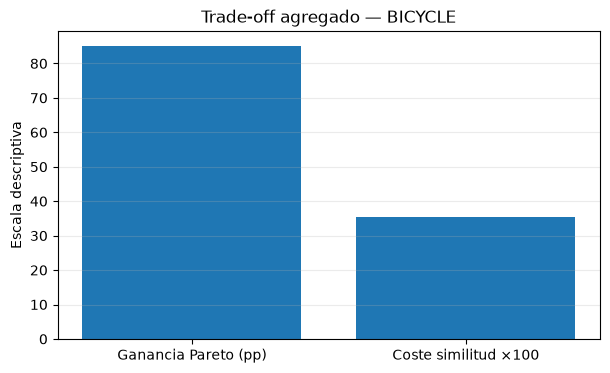

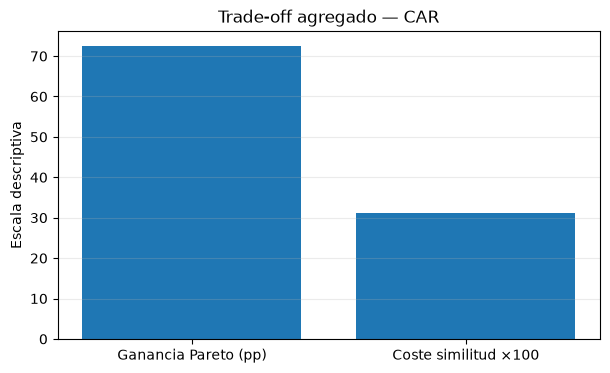

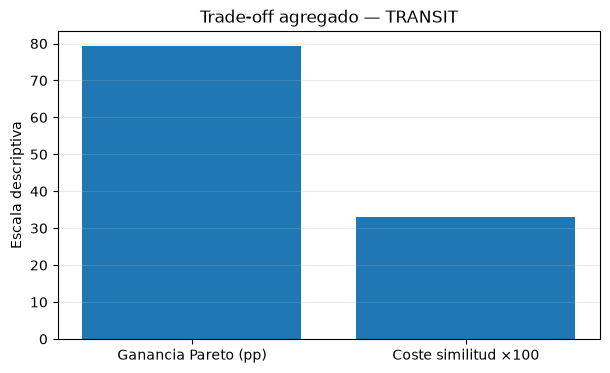

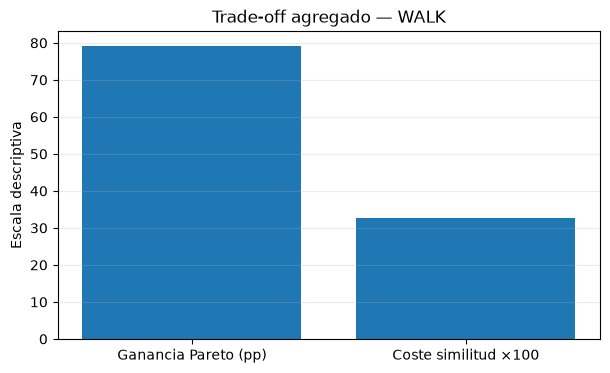

In [ ]:
for mode in sorted(mode_tradeoff["transport_mode"]):
    row = mode_tradeoff.loc[
        mode_tradeoff["transport_mode"].eq(mode)
    ].iloc[0]

    plt.figure(figsize=(7, 4))
    plt.bar(
        ["Ganancia Pareto (pp)", "Coste similitud ×100"],
        [
            row["mean_pareto_gain_pp"],
            100 * row["mean_similarity_cost_absolute"],
        ],
    )
    plt.title(f"Trade-off agregado — {mode}")
    plt.ylabel("Escala descriptiva")
    plt.grid(axis="y", alpha=0.25)
    plt.show()


**NOTA:** El gráfico utiliza dos magnitudes con unidades distintas y por eso se presenta únicamente como apoyo visual descriptivo. Las conclusiones cuantitativas se extraen de la tabla anterior, no de la altura relativa de las barras.


## 13.8 Diferenciación entre perfiles

El perfil del usuario determina la recomendación de referencia. Después, *Pareto + KNN* busca alternativas similares alrededor de esa referencia.

Se analiza el índice de Jaccard entre los conjuntos de vecinos de los tres perfiles. Valores próximos a 1 indican listas muy parecidas; valores bajos indican que las preferencias están generando alternativas diferentes.


In [ ]:
profile_differentiation = (
    profile_overlap.groupby(
        [
            "transport_mode",
            "profile_a",
            "profile_b",
        ],
        as_index=False,
    )
    .agg(
        groups=("destination_id", "size"),
        mean_jaccard=("jaccard", "mean"),
        median_jaccard=("jaccard", "median"),
        min_jaccard=("jaccard", "min"),
        max_jaccard=("jaccard", "max"),
    )
)

anchor_diversity = (
    anchors.groupby(
        [
            "destination_id",
            "transport_mode",
        ],
        as_index=False,
    )
    .agg(
        profiles=("profile_id", "nunique"),
        unique_anchor_zones=("anchor_zone_key", "nunique"),
    )
)

profile_changed_groups = int(
    (anchor_diversity["unique_anchor_zones"] > 1).sum()
)


In [ ]:
display(profile_differentiation)

,transport_mode,profile_a,profile_b,groups,mean_jaccard,median_jaccard,min_jaccard,max_jaccard
0,BICYCLE,balanced,price_priority,3,0.4722,0.5000,0.2500,0.6667
1,BICYCLE,balanced,time_priority,3,0.4537,0.2500,0.1111,1.0000
2,BICYCLE,price_priority,time_priority,3,0.2037,0.1111,0.0000,0.5000
3,CAR,balanced,price_priority,3,0.3466,0.4286,0.1111,0.5000
4,CAR,balanced,time_priority,3,0.4167,0.2500,0.0000,1.0000
5,CAR,price_priority,time_priority,3,0.2037,0.1111,0.0000,0.5000
6,TRANSIT,balanced,price_priority,3,0.6762,0.6000,0.4286,1.0000
7,TRANSIT,balanced,time_priority,3,1.0000,1.0000,1.0000,1.0000
8,TRANSIT,price_priority,time_priority,3,0.6762,0.6000,0.4286,1.0000
9,WALK,balanced,price_priority,3,0.3095,0.4286,0.0000,0.5000


In [ ]:
display(anchor_diversity)

,destination_id,transport_mode,profiles,unique_anchor_zones
0,DEST_001,BICYCLE,3,3
1,DEST_001,CAR,3,3
2,DEST_001,TRANSIT,3,2
3,DEST_001,WALK,3,3
4,DEST_002,BICYCLE,3,3
5,DEST_002,CAR,3,3
6,DEST_002,TRANSIT,3,2
7,DEST_002,WALK,3,3
8,DEST_003,BICYCLE,3,2
9,DEST_003,CAR,3,2


In [ ]:
print(
    "Grupos destino-modo donde los perfiles cambian la referencia:",
    f"{profile_changed_groups}/{len(anchor_diversity)}",
)

Grupos destino-modo donde los perfiles cambian la referencia: 12/12


## 13.9 Ablación del espacio de características

El notebook 12 compara dos representaciones:

- *objective_only*: precio y tiempo
- *extended*: precio, tiempo y características residenciales disponibles con cobertura suficiente

Aquí se resume cuánto cambia la lista de vecinos al utilizar la representación extendida. El objetivo no es afirmar que más variables sean siempre mejores, sino comprobar si añaden información suficiente como para modificar las alternativas recuperadas.


In [ ]:
feature_ablation = (
    feature_overlap.groupby(
        [
            "transport_mode",
            "method",
        ],
        as_index=False,
    )
    .agg(
        scenarios=("profile_id", "size"),
        mean_jaccard=("jaccard", "mean"),
        median_jaccard=("jaccard", "median"),
        unchanged_lists=(
            "jaccard",
            lambda s: int(np.isclose(s, 1.0, atol=FLOAT_TOL).sum()),
        ),
    )
)

feature_ablation["changed_lists"] = (
    feature_ablation["scenarios"]
    - feature_ablation["unchanged_lists"]
)

feature_ablation["changed_lists_pct"] = (
    100
    * feature_ablation["changed_lists"]
    / feature_ablation["scenarios"]
)

display(feature_ablation)


,transport_mode,method,scenarios,mean_jaccard,median_jaccard,unchanged_lists,changed_lists,changed_lists_pct
0,BICYCLE,KNN_global,9,0.2896,0.2500,0,9,100.0000
1,BICYCLE,Pareto_KNN,9,0.6058,0.4286,3,6,66.6667
2,CAR,KNN_global,9,0.2175,0.2000,0,9,100.0000
3,CAR,Pareto_KNN,9,0.6892,0.6667,4,5,55.5556
4,TRANSIT,KNN_global,9,0.1279,0.1429,0,9,100.0000
5,TRANSIT,Pareto_KNN,9,0.7328,1.0000,5,4,44.4444
6,WALK,KNN_global,9,0.2618,0.2000,0,9,100.0000
7,WALK,Pareto_KNN,9,0.5794,0.4286,3,6,66.6667


## 13.10 Sensibilidad al número de vecinos

Se utilizan los valores *k = 3, 5, 7, 10* ya calculados en el notebook 12. El objetivo es comprobar si las conclusiones dependen de un único valor de *k*.

En *Pareto + KNN*, la tasa Pareto debe permanecer en 100 % por construcción. Lo relevante es observar cómo evoluciona la distancia media a medida que se solicitan más alternativas.


In [ ]:
k_sensitivity = sensitivity.copy()

k_sensitivity = k_sensitivity.sort_values(
    [
        "transport_mode",
        "method",
        "requested_k",
    ]
).reset_index(drop=True)

display(k_sensitivity)


,transport_mode,method,requested_k,scenarios,mean_returned_neighbors,mean_pareto_rate_pct,mean_normalized_distance,mean_abs_price_change_pct,mean_abs_time_change_pct
0,BICYCLE,KNN_global,3,9,3.0000,18.5185,0.4334,26.7779,95.7306
1,BICYCLE,KNN_global,5,9,4.3333,14.8148,0.4739,27.1921,105.4701
2,BICYCLE,KNN_global,7,9,5.6667,16.4021,0.4984,26.8904,110.7802
3,BICYCLE,KNN_global,10,9,7.6667,18.1481,0.5296,29.3441,130.4897
4,BICYCLE,Pareto_KNN,3,9,3.0000,100.0000,0.7576,31.2727,118.3555
5,BICYCLE,Pareto_KNN,5,9,4.3333,100.0000,0.8270,36.5332,136.3771
6,BICYCLE,Pareto_KNN,7,9,5.6667,100.0000,0.8829,37.4527,146.1099
7,BICYCLE,Pareto_KNN,10,9,7.6667,100.0000,0.9622,41.4776,184.6416
8,CAR,KNN_global,3,9,3.0000,29.6296,0.4531,20.2880,30.7075
9,CAR,KNN_global,5,9,4.3333,27.4074,0.4906,23.0353,35.9211


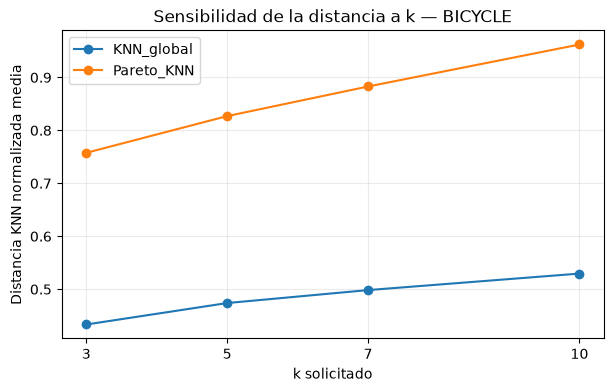

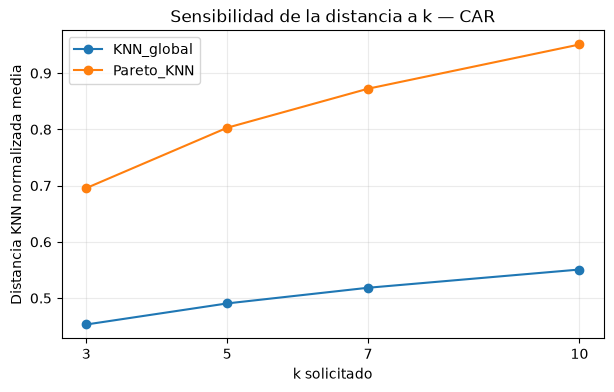

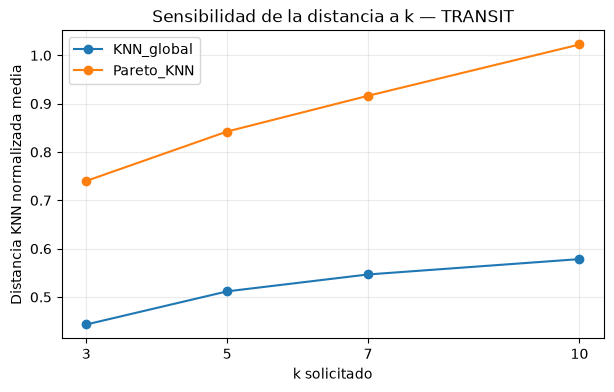

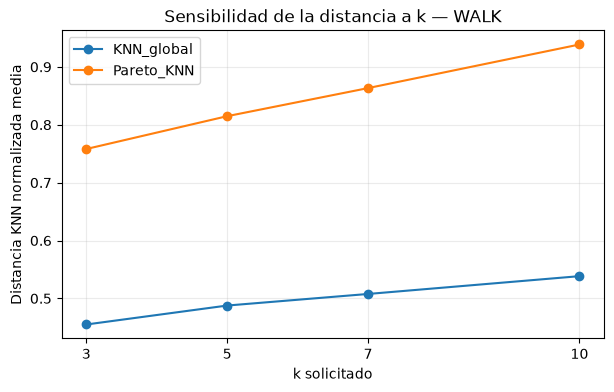

In [ ]:
for mode in sorted(k_sensitivity["transport_mode"].unique()):
    plot_data = k_sensitivity.loc[
        k_sensitivity["transport_mode"].eq(mode)
    ]

    plt.figure(figsize=(7, 4))

    for method, method_group in plot_data.groupby("method", sort=True):
        method_group = method_group.sort_values("requested_k")
        plt.plot(
            method_group["requested_k"],
            method_group["mean_normalized_distance"],
            marker="o",
            label=method,
        )

    plt.title(f"Sensibilidad de la distancia a k — {mode}")
    plt.xlabel("k solicitado")
    plt.ylabel("Distancia KNN normalizada media")
    plt.xticks(sorted(plot_data["requested_k"].unique()))
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()


## 13.11 Disponibilidad de vecinos

Un frente de Pareto puede ser pequeño. Por eso, el notebook 12 compara ambas estrategias con el mismo *comparison_k*, aunque sea inferior al *k* pedido.

Esta sección cuantifica cuántos escenarios pueden devolver los cinco vecinos completos y en cuáles el frente limita el número de alternativas.


In [ ]:
availability_summary = (
    availability.groupby(
        "transport_mode",
        as_index=False,
    )
    .agg(
        scenarios=("profile_id", "size"),
        mean_global_candidates=("global_candidates", "mean"),
        mean_pareto_candidates=("pareto_candidates", "mean"),
        mean_comparison_k=("comparison_k", "mean"),
        full_k_scenarios=(
            "full_k_available",
            lambda s: int(pd.Series(s).astype(bool).sum()),
        ),
    )
)

availability_summary["full_k_rate_pct"] = (
    100
    * availability_summary["full_k_scenarios"]
    / availability_summary["scenarios"]
)

display(availability_summary)


,transport_mode,scenarios,mean_global_candidates,mean_pareto_candidates,mean_comparison_k,full_k_scenarios,full_k_rate_pct
0,BICYCLE,9,128.0000,10.3333,4.3333,6,66.6667
1,CAR,9,120.0000,11.0000,4.3333,6,66.6667
2,TRANSIT,9,122.6667,8.3333,4.6667,6,66.6667
3,WALK,9,111.0000,11.6667,4.3333,6,66.6667


## 13.12 Caso representativo e interpretación de vecinos

Para evitar seleccionar manualmente un ejemplo favorable, se toma el escenario cuya *similarity_cost_absolute* está más cerca de la mediana global. Así se muestra un caso representativo del comportamiento observado.


In [ ]:
median_cost = tradeoff["similarity_cost_absolute"].median()

representative_idx = (
    (tradeoff["similarity_cost_absolute"] - median_cost)
    .abs()
    .idxmin()
)

representative = tradeoff.loc[representative_idx]

case_mask = (
    neighbors["destination_id"].astype(str).eq(
        str(representative["destination_id"])
    )
    & neighbors["transport_mode"].astype(str).eq(
        str(representative["transport_mode"])
    )
    & neighbors["profile_id"].astype(str).eq(
        str(representative["profile_id"])
    )
)

case_study = (
    neighbors.loc[
        case_mask,
        [
            "destination_id",
            "destination_name",
            "transport_mode",
            "profile_id",
            "method",
            "neighbor_rank",
            "anchor_zone_key",
            "anchor_neighborhood_name",
            "neighbor_zone_key",
            "neighbor_neighborhood_name",
            "neighbor_is_pareto",
            "normalized_knn_distance",
            "price_delta_pct",
            "time_delta_pct",
            "top_distance_drivers",
        ],
    ]
    .sort_values(["method", "neighbor_rank"])
    .reset_index(drop=True)
)

display(
    Markdown(
        f"""
### Escenario representativo

- **Destino:** {representative['destination_id']}
- **Modo:** {representative['transport_mode']}
- **Perfil:** {representative['profile_id']}
- **Coste de similitud:** {representative['similarity_cost_absolute']:.4f}
- **Ganancia Pareto:** {representative['pareto_gain_pp']:.2f} pp
- **Jaccard entre estrategias:** {representative['strategy_jaccard']:.3f}
"""
    )
)

display(case_study)



### Escenario representativo

- **Destino:** DEST_001
- **Modo:** WALK
- **Perfil:** time_priority
- **Coste de similitud:** 0.3163
- **Ganancia Pareto:** 80.00 pp
- **Jaccard entre estrategias:** 0.111


,destination_id,destination_name,transport_mode,profile_id,method,neighbor_rank,anchor_zone_key,anchor_neighborhood_name,neighbor_zone_key,neighbor_neighborhood_name,neighbor_is_pareto,normalized_knn_distance,price_delta_pct,time_delta_pct,top_distance_drivers
0,DEST_001,Puerta del Sol,WALK,time_priority,KNN_global,1,MAD-016,Sol,MAD-013,Cortes,True,0.2190,-5.8449,472.0721,exterior_ratio (48.0 %); elevator_ratio (28.0 ...
1,DEST_001,Puerta del Sol,WALK,time_priority,KNN_global,2,MAD-016,Sol,MAD-015,Universidad,False,0.4384,-7.2913,780.1802,exterior_ratio (84.9 %); commute_daily_minutes...
2,DEST_001,Puerta del Sol,WALK,time_priority,KNN_global,3,MAD-016,Sol,MAD-011,Palacio,False,0.5604,-10.4132,843.6937,exterior_ratio (84.6 %); price_m2_for_recommen...
3,DEST_001,Puerta del Sol,WALK,time_priority,KNN_global,4,MAD-016,Sol,MAD-031,Pacífico,False,0.6767,-18.3248,"2,218.9189",exterior_ratio (33.7 %); elevator_ratio (25.9 ...
4,DEST_001,Puerta del Sol,WALK,time_priority,KNN_global,5,MAD-016,Sol,MAD-014,Justicia,False,0.6852,23.9754,854.5045,rooms_median (55.5 %); price_m2_for_recommende...
5,DEST_001,Puerta del Sol,WALK,time_priority,Pareto_KNN,1,MAD-016,Sol,MAD-013,Cortes,True,0.2190,-5.8449,472.0721,exterior_ratio (48.0 %); elevator_ratio (28.0 ...
6,DEST_001,Puerta del Sol,WALK,time_priority,Pareto_KNN,2,MAD-016,Sol,MAD-022,Acacias,True,0.9270,-25.4678,"1,762.6126",exterior_ratio (72.5 %); price_m2_for_recommen...
7,DEST_001,Puerta del Sol,WALK,time_priority,Pareto_KNN,3,MAD-016,Sol,MAD-125,Moscardó,True,0.9886,-51.4178,"2,623.4234",price_m2_for_recommender (48.8 %); rooms_media...
8,DEST_001,Puerta del Sol,WALK,time_priority,Pareto_KNN,4,MAD-016,Sol,MAD-113,San Isidro,True,0.9991,-52.3163,"2,631.9820",price_m2_for_recommender (49.5 %); exterior_ra...
9,DEST_001,Puerta del Sol,WALK,time_priority,Pareto_KNN,5,MAD-016,Sol,MAD-023,Chopera,True,1.0278,-28.8793,"2,000.9009",bathrooms_median (46.6 %); elevator_ratio (25....


## 13.13 Hallazgos empíricos

Los siguientes resultados se presentan como hallazgos descriptivos, no como contratos estructurales ni como métricas de precisión predictiva.

No existe una etiqueta de “barrio correcto” obtenida de usuarios reales, por lo que no procede utilizar *accuracy*, *MAE* o R² para evaluar KNN en este contexto.


In [ ]:
scenarios_with_dominated = int(
    (tradeoff["global_dominated_neighbors"] > 0).sum()
)

global_dominated_share = (
    100 * scenarios_with_dominated / len(tradeoff)
)

mean_profile_jaccard = float(
    profile_overlap["jaccard"].mean()
)

mean_feature_jaccard = float(
    feature_overlap["jaccard"].mean()
)

mean_strategy_jaccard = float(
    tradeoff["strategy_jaccard"].mean()
)

full_k_total = int(
    availability["full_k_available"].astype(bool).sum()
)

full_k_rate = (
    100 * full_k_total / len(availability)
)

findings = pd.DataFrame(
    [
        {
            "finding_id": "F1",
            "finding": (
                "KNN global recupera alternativas dominadas "
                "en parte de los escenarios."
            ),
            "value": global_dominated_share,
            "unit": "% de escenarios",
            "evidence": (
                f"{scenarios_with_dominated}/{len(tradeoff)} escenarios"
            ),
        },
        {
            "finding_id": "F2",
            "finding": (
                "Exigir Pareto aumenta la distancia media de similitud."
            ),
            "value": tradeoff["similarity_cost_absolute"].mean(),
            "unit": "distancia normalizada",
            "evidence": (
                "Media de la diferencia Pareto_KNN - KNN_global."
            ),
        },
        {
            "finding_id": "F3",
            "finding": (
                "Las dos estrategias recuperan conjuntos de vecinos "
                "parcialmente diferentes."
            ),
            "value": mean_strategy_jaccard,
            "unit": "Jaccard medio",
            "evidence": (
                "Solapamiento de vecinos por destino-modo-perfil."
            ),
        },
        {
            "finding_id": "F4",
            "finding": (
                "Los perfiles de usuario producen conjuntos "
                "de vecinos diferenciados."
            ),
            "value": mean_profile_jaccard,
            "unit": "Jaccard medio",
            "evidence": (
                f"{profile_changed_groups}/{len(anchor_diversity)} "
                "grupos cambian además la referencia principal."
            ),
        },
        {
            "finding_id": "F5",
            "finding": (
                "El espacio extendido modifica las listas respecto "
                "a utilizar solo precio y tiempo."
            ),
            "value": mean_feature_jaccard,
            "unit": "Jaccard medio",
            "evidence": (
                "Ablación objective_only frente a extended."
            ),
        },
        {
            "finding_id": "F6",
            "finding": (
                "El frente Pareto permite devolver k=5 completo "
                "en una parte de los escenarios."
            ),
            "value": full_k_rate,
            "unit": "% de escenarios",
            "evidence": (
                f"{full_k_total}/{len(availability)} escenarios"
            ),
        },
    ]
)

display(findings)


,finding_id,finding,value,unit,evidence
0,F1,KNN global recupera alternativas dominadas en ...,100.0000,% de escenarios,36/36 escenarios
1,F2,Exigir Pareto aumenta la distancia media de si...,0.3308,distancia normalizada,Media de la diferencia Pareto_KNN - KNN_global.
2,F3,Las dos estrategias recuperan conjuntos de vec...,0.1326,Jaccard medio,Solapamiento de vecinos por destino-modo-perfil.
3,F4,Los perfiles de usuario producen conjuntos de ...,0.4343,Jaccard medio,12/12 grupos cambian además la referencia prin...
4,F5,El espacio extendido modifica las listas respe...,0.4380,Jaccard medio,Ablación objective_only frente a extended.
5,F6,El frente Pareto permite devolver k=5 completo...,66.6667,% de escenarios,24/36 escenarios


## 13.14 Validaciones estructurales

Estas validaciones comprueban integridad, reproducibilidad y coherencia entre archivos. No convierten los hallazgos empíricos anteriores en condiciones de aprobado/suspenso.


In [ ]:
validation_rows = []


def add_validation(
    validation_id: str,
    description: str,
    passed: bool,
    detail: str,
) -> None:
    validation_rows.append(
        {
            "validation_id": validation_id,
            "validation_type": "structural",
            "description": description,
            "passed": bool(passed),
            "detail": detail,
        }
    )


add_validation(
    "notebook12_contract",
    "Todas las validaciones estructurales del notebook 12 están superadas.",
    validation12["passed"].all(),
    f"Superadas: {int(validation12['passed'].sum())}/{len(validation12)}",
)

add_validation(
    "exact_transport_modes",
    "Están presentes exactamente los cuatro modos del sistema.",
    set(modes) == EXPECTED_MODES,
    f"Modos: {modes}",
)

add_validation(
    "scenario_matrix_complete",
    "La matriz destino-modo-perfil está completa.",
    len(comparison) == expected_scenarios,
    f"Esperados: {expected_scenarios}; presentes: {len(comparison)}",
)

add_validation(
    "unique_scenarios",
    "No hay escenarios destino-modo-perfil duplicados.",
    scenario_duplicates == 0,
    f"Duplicados: {scenario_duplicates}",
)

missing_core = int(
    tradeoff[
        [
            "global_pareto_rate_pct",
            "hybrid_pareto_rate_pct",
            "global_mean_distance",
            "hybrid_mean_distance",
            "pareto_gain_pp",
            "similarity_cost_absolute",
            "strategy_jaccard",
        ]
    ].isna().any(axis=1).sum()
)

add_validation(
    "complete_core_metrics",
    "Las métricas principales están completas.",
    missing_core == 0,
    f"Filas incompletas: {missing_core}",
)

add_validation(
    "hybrid_is_pareto",
    "Pareto_KNN devuelve 100 % de vecinos Pareto por construcción.",
    np.allclose(
        comparison["hybrid_pareto_rate_pct"],
        100.0,
        atol=1e-9,
    ),
    (
        f"Mínimo observado: "
        f"{comparison['hybrid_pareto_rate_pct'].min():.4f}%"
    ),
)

add_validation(
    "fair_neighbor_count",
    "Las dos estrategias se comparan con el mismo número de vecinos.",
    (
        comparison["global_returned_neighbors"]
        == comparison["hybrid_returned_neighbors"]
    ).all(),
    (
        "Escenarios desiguales: "
        f"{int((comparison['global_returned_neighbors'] != comparison['hybrid_returned_neighbors']).sum())}"
    ),
)

add_validation(
    "nonnegative_similarity_cost",
    "La restricción a un subconjunto Pareto no reduce artificialmente la distancia media.",
    (comparison["similarity_cost_absolute"] >= -FLOAT_TOL).all(),
    (
        "Mínimo: "
        f"{comparison['similarity_cost_absolute'].min():.12f}"
    ),
)

add_validation(
    "nonnegative_pareto_gain",
    "La restricción Pareto no reduce la proporción de vecinos eficientes.",
    (comparison["pareto_gain_pp"] >= -FLOAT_TOL).all(),
    (
        "Mínimo: "
        f"{comparison['pareto_gain_pp'].min():.8f} pp"
    ),
)


def bounded_zero_one(series: pd.Series) -> bool:
    values = pd.to_numeric(series, errors="coerce")
    return bool(
        values.notna().all()
        and (values >= -FLOAT_TOL).all()
        and (values <= 1 + FLOAT_TOL).all()
    )


add_validation(
    "strategy_jaccard_bounds",
    "Los Jaccard entre estrategias están en [0, 1].",
    bounded_zero_one(strategy_overlap["jaccard"]),
    (
        f"Rango: {strategy_overlap['jaccard'].min():.4f}–"
        f"{strategy_overlap['jaccard'].max():.4f}"
    ),
)

add_validation(
    "profile_jaccard_bounds",
    "Los Jaccard entre perfiles están en [0, 1].",
    bounded_zero_one(profile_overlap["jaccard"]),
    (
        f"Rango: {profile_overlap['jaccard'].min():.4f}–"
        f"{profile_overlap['jaccard'].max():.4f}"
    ),
)

add_validation(
    "feature_jaccard_bounds",
    "Los Jaccard de la ablación están en [0, 1].",
    bounded_zero_one(feature_overlap["jaccard"]),
    (
        f"Rango: {feature_overlap['jaccard'].min():.4f}–"
        f"{feature_overlap['jaccard'].max():.4f}"
    ),
)

anchor_duplicates = int(
    anchors.duplicated(
        subset=[
            "destination_id",
            "transport_mode",
            "profile_id",
        ]
    ).sum()
)

add_validation(
    "unique_anchors",
    "Existe como máximo una referencia por destino-modo-perfil.",
    anchor_duplicates == 0,
    f"Duplicados: {anchor_duplicates}",
)

add_validation(
    "anchor_coverage",
    "Existe una referencia para cada escenario experimental.",
    len(anchors) == expected_scenarios,
    f"Esperadas: {expected_scenarios}; presentes: {len(anchors)}",
)

add_validation(
    "evaluation_methods",
    "La evaluación contiene exactamente KNN_global y Pareto_KNN.",
    set(evaluation["method"].astype(str).unique()) == EXPECTED_METHODS,
    f"Métodos: {sorted(evaluation['method'].astype(str).unique())}",
)

expected_evaluation_rows = expected_scenarios * len(EXPECTED_METHODS)

add_validation(
    "paired_evaluation_coverage",
    "Cada escenario tiene una fila de evaluación por estrategia.",
    len(evaluation) == expected_evaluation_rows,
    (
        f"Esperadas: {expected_evaluation_rows}; "
        f"presentes: {len(evaluation)}"
    ),
)

observed_k_values = set(
    pd.to_numeric(
        sensitivity["requested_k"],
        errors="coerce",
    ).dropna().astype(int)
)

add_validation(
    "sensitivity_k_values",
    "La sensibilidad cubre k = 3, 5, 7 y 10.",
    observed_k_values == EXPECTED_K_VALUES,
    f"k observados: {sorted(observed_k_values)}",
)

add_validation(
    "sensitivity_modes",
    "La sensibilidad cubre los cuatro modos.",
    set(sensitivity["transport_mode"].astype(str)) == EXPECTED_MODES,
    (
        "Modos: "
        f"{sorted(sensitivity['transport_mode'].astype(str).unique())}"
    ),
)

add_validation(
    "sensitivity_methods",
    "La sensibilidad cubre ambas estrategias.",
    set(sensitivity["method"].astype(str)) == EXPECTED_METHODS,
    (
        "Métodos: "
        f"{sorted(sensitivity['method'].astype(str).unique())}"
    ),
)

hybrid_sensitivity = sensitivity.loc[
    sensitivity["method"].astype(str).eq("Pareto_KNN")
]

add_validation(
    "hybrid_pareto_across_k",
    "Pareto_KNN conserva 100 % de vecinos Pareto para todos los k.",
    np.allclose(
        hybrid_sensitivity["mean_pareto_rate_pct"],
        100.0,
        atol=1e-9,
    ),
    (
        "Mínimo: "
        f"{hybrid_sensitivity['mean_pareto_rate_pct'].min():.4f}%"
    ),
)

add_validation(
    "mode_summary_coverage",
    "El resumen por modo contiene una fila para cada modo.",
    (
        len(mode_tradeoff) == len(EXPECTED_MODES)
        and set(mode_tradeoff["transport_mode"]) == EXPECTED_MODES
    ),
    f"Filas: {len(mode_tradeoff)}",
)

bootstrap_repeat = bootstrap_mean_ci(
    tradeoff["similarity_cost_absolute"],
    seed=RANDOM_STATE,
)

bootstrap_original = bootstrap_summary.loc[
    bootstrap_summary["metric"].eq("similarity_cost_absolute")
].iloc[0]

bootstrap_deterministic = (
    np.isclose(
        bootstrap_repeat["mean"],
        bootstrap_original["mean"],
        atol=1e-12,
    )
    and np.isclose(
        bootstrap_repeat["ci_low"],
        bootstrap_original["ci_low"],
        atol=1e-12,
    )
    and np.isclose(
        bootstrap_repeat["ci_high"],
        bootstrap_original["ci_high"],
        atol=1e-12,
    )
)

add_validation(
    "bootstrap_determinism",
    "El bootstrap es reproducible con la semilla fijada.",
    bootstrap_deterministic,
    f"Iteraciones: {BOOTSTRAP_ITERATIONS}",
)

validation_report = pd.DataFrame(validation_rows)
display(validation_report)

failed_validations = validation_report.loc[
    ~validation_report["passed"]
]

if not failed_validations.empty:
    display(Markdown("### Validaciones no superadas"))
    display(failed_validations)
    raise AssertionError(
        "El notebook 13 no ha superado todas "
        "las validaciones estructurales."
    )

print(
    "Todas las validaciones estructurales "
    "del notebook 13 se han superado correctamente."
)


,validation_id,validation_type,description,passed,detail
0,notebook12_contract,structural,Todas las validaciones estructurales del noteb...,True,Superadas: 23/23
1,exact_transport_modes,structural,Están presentes exactamente los cuatro modos d...,True,"Modos: ['BICYCLE', 'CAR', 'TRANSIT', 'WALK']"
2,scenario_matrix_complete,structural,La matriz destino-modo-perfil está completa.,True,Esperados: 36; presentes: 36
3,unique_scenarios,structural,No hay escenarios destino-modo-perfil duplicados.,True,Duplicados: 0
4,complete_core_metrics,structural,Las métricas principales están completas.,True,Filas incompletas: 0
5,hybrid_is_pareto,structural,Pareto_KNN devuelve 100 % de vecinos Pareto po...,True,Mínimo observado: 100.0000%
6,fair_neighbor_count,structural,Las dos estrategias se comparan con el mismo n...,True,Escenarios desiguales: 0
7,nonnegative_similarity_cost,structural,La restricción a un subconjunto Pareto no redu...,True,Mínimo: 0.067296616554
8,nonnegative_pareto_gain,structural,La restricción Pareto no reduce la proporción ...,True,Mínimo: 40.00000000 pp
9,strategy_jaccard_bounds,structural,"Los Jaccard entre estrategias están en [0, 1].",True,Rango: 0.0000–0.4286


Todas las validaciones estructurales del notebook 13 se han superado correctamente.


## 13.15 Síntesis para la memoria

La tabla final reúne resultados empíricos y validaciones, manteniendo separados ambos conceptos.


In [ ]:
overall_summary = pd.Series(
    {
        "destinations": len(destinations),
        "transport_modes": len(modes),
        "profiles": len(profiles),
        "experimental_scenarios": len(tradeoff),
        "scenarios_with_dominated_global_neighbors": scenarios_with_dominated,
        "scenarios_with_dominated_global_neighbors_pct": global_dominated_share,
        "mean_global_pareto_rate_pct": tradeoff["global_pareto_rate_pct"].mean(),
        "mean_pareto_gain_pp": tradeoff["pareto_gain_pp"].mean(),
        "mean_similarity_cost_absolute": tradeoff["similarity_cost_absolute"].mean(),
        "median_similarity_cost_pct": tradeoff["similarity_cost_pct"].median(),
        "mean_strategy_jaccard": mean_strategy_jaccard,
        "mean_profile_jaccard": mean_profile_jaccard,
        "mean_feature_space_jaccard": mean_feature_jaccard,
        "groups_with_profile_dependent_anchor": profile_changed_groups,
        "destination_mode_groups": len(anchor_diversity),
        "full_k5_scenarios": full_k_total,
        "full_k5_rate_pct": full_k_rate,
        "structural_validations_passed": int(validation_report["passed"].sum()),
        "structural_validations_total": len(validation_report),
    },
    name="value",
).to_frame()

display(overall_summary)


,value
destinations,3.0000
transport_modes,4.0000
profiles,3.0000
experimental_scenarios,36.0000
scenarios_with_dominated_global_neighbors,36.0000
scenarios_with_dominated_global_neighbors_pct,100.0000
mean_global_pareto_rate_pct,20.8796
mean_pareto_gain_pp,79.1204
mean_similarity_cost_absolute,0.3308
median_similarity_cost_pct,60.7673


## 13.16 Exportación reproducible

Las salidas se guardan con el prefijo *evaluation13_multimodal_* para no sobrescribir los resultados experimentales de los notebooks anteriores.


In [ ]:
EXPORTS = {
    OUTPUT_PATHS["bootstrap"]: bootstrap_summary,
    OUTPUT_PATHS["mode_tradeoff"]: mode_tradeoff,
    OUTPUT_PATHS["profile"]: profile_differentiation,
    OUTPUT_PATHS["feature"]: feature_ablation,
    OUTPUT_PATHS["sensitivity"]: k_sensitivity,
    OUTPUT_PATHS["findings"]: findings,
    OUTPUT_PATHS["case_study"]: case_study,
    OUTPUT_PATHS["validation"]: validation_report,
    OUTPUT_PATHS["summary"]: overall_summary,
}

for path, frame in EXPORTS.items():
    frame.to_csv(
        path,
        index=(path == OUTPUT_PATHS["summary"]),
        encoding="utf-8-sig",
    )

missing_exports = [
    path for path in EXPORTS
    if not path.exists()
]

if missing_exports:
    raise FileNotFoundError(
        "No se han generado todos los resultados del notebook 13: "
        f"{missing_exports}"
    )

print("Archivos generados correctamente:")

for path in EXPORTS:
    print("-", path.relative_to(PROJECT_ROOT))


Archivos generados correctamente:
- data/results/evaluation13_multimodal_bootstrap_summary.csv
- data/results/evaluation13_multimodal_tradeoff_by_mode.csv
- data/results/evaluation13_multimodal_profile_differentiation.csv
- data/results/evaluation13_multimodal_feature_ablation.csv
- data/results/evaluation13_multimodal_k_sensitivity.csv
- data/results/evaluation13_multimodal_empirical_findings.csv
- data/results/evaluation13_multimodal_case_study.csv
- data/results/evaluation13_multimodal_validation_report.csv
- data/results/evaluation13_multimodal_summary.csv


## 13.17 Limitaciones

Esta evaluación debe interpretarse dentro del alcance real de este proyecto:
- La frontera de Pareto garantiza eficiencia únicamente respecto a los dos objetivos considerados: precio y tiempo.
- La distancia **KNN** depende de las variables disponibles y de su estandarización dentro de cada *destino–modo.*
- La comparación entre modos se realiza sobre métricas agregadas; las distancias KNN se calculan dentro de cada grupo y no constituyen una escala física universal.
- Los intervalos *bootstrap* describen estabilidad del experimento actual y no deben interpretarse como intervalos de confianza poblacionales sobre todos los posibles usuarios.
- Un frente Pareto pequeño puede limitar el número de vecinos disponibles; por eso ambas estrategias se comparan con el mismo *comparison_k*.


In [ ]:
display(
    Markdown(
        f"""
### Resultado final

**Todas las validaciones estructurales del notebook 13 se han superado correctamente.**

Se han evaluado **{len(tradeoff)} escenarios destino–modo–perfil**, correspondientes a **{len(destinations)} destinos**, **{len(modes)} modos de transporte** y **{len(profiles)} perfiles**.

El análisis compara KNN global y Pareto + KNN, cuantifica el coste de similitud, estudia sensibilidad a `k`, perfiles, características y modos, e incorpora incertidumbre descriptiva mediante bootstrap.

**Notebook 13 multimodal finalizado correctamente.**
"""
    )
)



### Resultado final

**Todas las validaciones estructurales del notebook 13 se han superado correctamente.**

Se han evaluado **36 escenarios destino–modo–perfil**, correspondientes a **3 destinos**, **4 modos de transporte** y **3 perfiles**.

El análisis compara KNN global y Pareto + KNN, cuantifica el coste de similitud, estudia sensibilidad a `k`, perfiles, características y modos, e incorpora incertidumbre descriptiva mediante bootstrap.

**Notebook 13 multimodal finalizado correctamente.**


In [ ]:
FIGURES_DIR = PROJECT_ROOT / "figures_memoria"
FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def save_memory_figure(
    fig,
    filename: str,
) -> None:

    fig.savefig(
        FIGURES_DIR / f"{filename}.pdf",
        bbox_inches="tight",
    )

    fig.savefig(
        FIGURES_DIR / f"{filename}.png",
        dpi=300,
        bbox_inches="tight",
    )

    print(
        "Figura guardada:",
        FIGURES_DIR / f"{filename}.pdf",
    )

In [ ]:
# ============================================================
# FIGURA MEMORIA 5.5
# Trade-off entre eficiencia Pareto y similitud por modo
# ============================================================

knn_mode_plot = (
    tradeoff.groupby(
        "transport_mode",
        as_index=False,
    )
    .agg(
        global_pareto_rate_pct=(
            "global_pareto_rate_pct",
            "mean",
        ),
        median_similarity_cost_pct=(
            "similarity_cost_pct",
            "median",
        ),
    )
)

mode_order = [
    "BICYCLE",
    "CAR",
    "TRANSIT",
    "WALK",
]

mode_labels = {
    "BICYCLE":
        "Bicicleta",
    "CAR":
        "Coche",
    "TRANSIT":
        "Transporte público",
    "WALK":
        "A pie",
}

knn_mode_plot[
    "transport_mode"
] = pd.Categorical(
    knn_mode_plot[
        "transport_mode"
    ],
    categories=mode_order,
    ordered=True,
)

knn_mode_plot = (
    knn_mode_plot
    .sort_values(
        "transport_mode"
    )
    .reset_index(drop=True)
)

knn_mode_plot[
    "mode_label"
] = (
    knn_mode_plot[
        "transport_mode"
    ]
    .astype(str)
    .map(mode_labels)
)

knn_mode_plot[
    "pareto_knn_rate_pct"
] = 100.0

x = np.arange(
    len(
        knn_mode_plot
    )
)

width = 0.36

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    constrained_layout=True,
)

# ------------------------------------------------------------
# Panel A: proporción de vecinos Pareto
# ------------------------------------------------------------

axes[0].bar(
    x - width / 2,
    knn_mode_plot[
        "global_pareto_rate_pct"
    ],
    width,
    label="KNN global",
)

axes[0].bar(
    x + width / 2,
    knn_mode_plot[
        "pareto_knn_rate_pct"
    ],
    width,
    label="Pareto + KNN",
)

axes[0].set_xticks(
    x
)

axes[0].set_xticklabels(
    knn_mode_plot[
        "mode_label"
    ],
    rotation=20,
    ha="right",
)

axes[0].set_ylabel(
    "Vecinos eficientes de Pareto (%)"
)

axes[0].set_ylim(
    0,
    105,
)

axes[0].set_title(
    "(a) Eficiencia de los vecinos"
)

axes[0].grid(
    axis="y",
    alpha=0.25,
)

axes[0].legend()

# ------------------------------------------------------------
# Panel B: coste de similitud
# ------------------------------------------------------------

bars = axes[1].bar(
    x,
    knn_mode_plot[
        "median_similarity_cost_pct"
    ],
)

axes[1].bar_label(
    bars,
    fmt="%.1f %%",
    padding=3,
)

axes[1].set_xticks(
    x
)

axes[1].set_xticklabels(
    knn_mode_plot[
        "mode_label"
    ],
    rotation=20,
    ha="right",
)

axes[1].set_ylabel(
    "Incremento mediano de la distancia (%)"
)

axes[1].set_title(
    "(b) Coste relativo de similitud"
)

axes[1].grid(
    axis="y",
    alpha=0.25,
)

save_memory_figure(
    fig,
    "fig_5_5_tradeoff_knn_modos",
)

plt.show()